## **Phần 2: Xây dựng Mô hình Chẩn đoán và Phân loại Chất lượng Không khí**

Dự án này sử dụng dữ liệu lịch sử chất lượng không khí Việt Nam năm 2020 để huấn luyện các mô hình Machine Learning nhằm chẩn đoán nguồn ô nhiễm (Clustering) và dự báo mức độ ô nhiễm (Classification).

### 0. Thiết lập Môi trường và Tải Thư viện

In [1]:
# Thiết lập Môi trường và Tải Thư viện
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

# Import các thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

### 1. Thu thập và Tiền xử lý Dữ liệu

Dữ liệu ban đầu đang ở dạng "dài" (long format), cần được chuyển sang dạng "rộng" (wide format) để mỗi dòng là một quan sát duy nhất (ngày/thành phố) với các chỉ số ô nhiễm là các cột.

### 1.1: Tải, Chuyển đổi Định dạng và Xử lý Cơ bản

In [2]:
# 1. Tải dữ liệu
file_name = '/kaggle/input/dataset-on-air-quality-in-vietnam-in-2020/aqi_airqualitydata_2020_en.csv'
df = pd.read_csv(file_name)

# 2. Lọc và Pivot (Chuyển đổi sang định dạng Rộng)
# Chúng ta sẽ sử dụng giá trị 'median' làm đại diện cho nồng độ chất ô nhiễm trong ngày.
df_pivot = df.pivot_table(
    index=['Date', 'Country', 'City'], 
    columns='Specie', 
    values='median'
).reset_index()

# 3. Chuyển đổi cột 'Date' sang datetime và xử lý giá trị NaN
# Cột Date có định dạng DD/MM/YYYY
df_pivot['Date'] = pd.to_datetime(df_pivot['Date'], format='%d/%m/%Y')
df_pivot = df_pivot.set_index('Date')

# Xử lý NaN: Thay thế bằng giá trị trung bình (mean) của từng cột.
# Chúng ta chỉ xử lý các cột có giá trị số (pollutants)
pollutant_cols = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co']
for col in pollutant_cols:
    if col in df_pivot.columns:
        df_pivot[col] = df_pivot[col].fillna(df_pivot[col].mean())

# Hiển thị 5 dòng đầu sau khi Pivot và Tiền xử lý
print("DataFrame sau khi Pivot và Xử lý NaN:")
print(df_pivot[pollutant_cols].head())
print("\nThông tin dữ liệu sau khi xử lý:")
print(df_pivot.info())

DataFrame sau khi Pivot và Xử lý NaN:
Specie       pm25       pm10         o3        no2       so2        co
Date                                                                  
2020-01-01   83.0  52.000000   6.000000  26.000000  9.329677  3.911415
2020-01-01  164.0  83.000000   4.000000  17.900000  4.000000  0.300000
2020-01-01   74.0  24.723769   9.562601  10.428621  9.329677  3.911415
2020-01-01   18.0  13.000000  11.000000   4.000000  5.000000  5.000000
2021-01-01   34.0  23.000000  30.000000   9.000000  9.329677  3.911415

Thông tin dữ liệu sau khi xử lý:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1824 entries, 2020-01-01 to 2020-12-31
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country        1824 non-null   object 
 1   City           1824 non-null   object 
 2   aqi            219 non-null    float64
 3   co             1824 non-null   float64
 4   dew            1747 non-null   float6

### 1.2: Kỹ thuật Đặc trưng (Feature Engineering)

Trích xuất các đặc trưng thời gian để nắm bắt các mô hình ô nhiễm theo chu kỳ (ví dụ: giờ cao điểm, mùa).

In [3]:
# Kỹ thuật Đặc trưng (Feature Engineering)

# Trích xuất các thành phần thời gian từ index (Date)
df_pivot['Month'] = df_pivot.index.month
df_pivot['DayOfWeek'] = df_pivot.index.dayofweek # 0=Thứ Hai, 6=Chủ Nhật
df_pivot['DayOfYear'] = df_pivot.index.dayofyear # 1-365

# Giữ lại các cột quan trọng cho mô hình AI
analysis_df = df_pivot[['City'] + pollutant_cols + ['Month', 'DayOfWeek', 'DayOfYear']].copy()

print("DataFrame với các Feature thời gian:")
print(analysis_df.head())

DataFrame với các Feature thời gian:
Specie                  City   pm25       pm10         o3        no2  \
Date                                                                   
2020-01-01           Ha Long   83.0  52.000000   6.000000  26.000000   
2020-01-01            Ha Noi  164.0  83.000000   4.000000  17.900000   
2020-01-01  Ho Chi Minh City   74.0  24.723769   9.562601  10.428621   
2020-01-01               Hue   18.0  13.000000  11.000000   4.000000   
2021-01-01           Ha Long   34.0  23.000000  30.000000   9.000000   

Specie           so2        co  Month  DayOfWeek  DayOfYear  
Date                                                         
2020-01-01  9.329677  3.911415      1          2          1  
2020-01-01  4.000000  0.300000      1          2          1  
2020-01-01  9.329677  3.911415      1          2          1  
2020-01-01  5.000000  5.000000      1          2          1  
2021-01-01  9.329677  3.911415      1          4          1  


### 2. Xây dựng Mô hình Chẩn đoán AICell

### 2.1: Tạo Cột Mục tiêu Phân loại (AQI Classification)

Chúng ta sẽ tạo cột mục tiêu AQI_Class dựa trên chỉ số $\text{PM2.5}$, vì nó thường là chất gây ô nhiễm chính ở Việt Nam.

In [4]:
# Tạo Cột Mục tiêu Phân loại (AQI Classification)

# Hàm phân loại AQI dựa trên PM2.5 (Tiêu chuẩn US EPA)
def classify_aqi(pm25):
    if pm25 <= 12.0: return 0  # Tốt (Good)
    elif pm25 <= 35.4: return 1  # Trung bình (Moderate)
    elif pm25 <= 55.4: return 2  # Kém (Unhealthy for sensitive groups)
    elif pm25 <= 150.4: return 3  # Xấu (Unhealthy)
    else: return 4  # Nguy hại (Hazardous)

# Tạo cột mục tiêu
analysis_df['AQI_Class'] = analysis_df['pm25'].apply(classify_aqi)

print("Phân bố Mức độ AQI:")
print(analysis_df['AQI_Class'].value_counts().sort_index())

Phân bố Mức độ AQI:
AQI_Class
0    201
1    589
2    394
3    613
4     27
Name: count, dtype: int64


### 2.2: Phân tích Tương quan (EDA Chuyên sâu)

Phân tích mối quan hệ giữa các chất gây ô nhiễm để hỗ trợ việc chẩn đoán nguồn gốc.

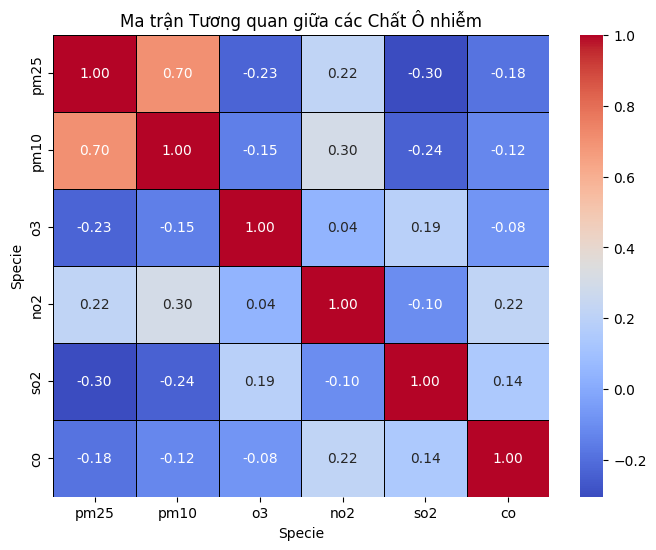

In [5]:
# Phân tích Tương quan Chất lượng Không khí

# Tính toán ma trận tương quan giữa các chất ô nhiễm chính
corr_matrix = analysis_df[pollutant_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=.5, linecolor='black')
plt.title('Ma trận Tương quan giữa các Chất Ô nhiễm')
plt.show()

# Phân tích Chẩn đoán sơ bộ:
# Quan sát mối tương quan cao (ví dụ: pm25 và no2) có thể gợi ý nguồn phát thải chung
# (thường là giao thông hoặc đốt nhiên liệu).

### 2.3: Phân tích Cụm (K-Means Clustering) - Chẩn đoán Kiểu Ô nhiễm

Phân tích cụm giúp nhóm các ngày/trạm có "hồ sơ ô nhiễm" tương tự nhau để xác định các kiểu ô nhiễm chính.

In [6]:
# Phân tích Cụm (K-Means Clustering) - Chẩn đoán Kiểu Ô nhiễm

# 1. Chuẩn hóa Dữ liệu
clustering_features = analysis_df[pollutant_cols]
scaler = StandardScaler()
X_scaled_clustering = scaler.fit_transform(clustering_features)

# Lưu StandardScaler để xử lý dữ liệu thời gian thực sau này
joblib.dump(scaler, 'scaler_clustering.joblib')

# 2. Tìm K tối ưu bằng Elbow Method (chọn K=3 hoặc K=4 là hợp lý cho các kiểu ô nhiễm chính)
# Ở đây chúng ta sẽ chọn K=4 để có đủ 4 kiểu ô nhiễm chính (Thấp, Trung bình, Cao/Bụi, Cao/Khí)
K_optimal = 4

# 3. Áp dụng K-Means
kmeans = KMeans(n_clusters=K_optimal, random_state=42, n_init=10)
analysis_df['Cluster_Label'] = kmeans.fit_predict(X_scaled_clustering)

# 4. Phân tích Kết quả Chẩn đoán
cluster_summary = analysis_df.groupby('Cluster_Label')[pollutant_cols].mean()

print(f"Giá trị Trung bình các Chất Ô nhiễm theo {K_optimal} Cụm:")
print(cluster_summary)

# Chẩn đoán: Dựa vào bảng tóm tắt, bạn có thể đặt tên cho từng cụm:
# Ví dụ: Cụm 0 (Low), Cụm 1 (High PM2.5), Cụm 2 (Medium), Cụm 3 (High NO2/CO)

# Lưu mô hình Clustering
joblib.dump(kmeans, 'kmeans_diagnosis_model.joblib')

Giá trị Trung bình các Chất Ô nhiễm theo 4 Cụm:
Specie               pm25       pm10         o3        no2        so2  \
Cluster_Label                                                           
0               60.553916  25.385221   8.853422   8.897631   7.206456   
1               26.331595  17.075556  10.036762   6.431111  19.182222   
2               24.572245  19.590036  11.121296  12.129480   9.071828   
3              108.644970  52.387264   5.900827  15.835252   6.749719   

Specie               co  
Cluster_Label            
0              2.971704  
1              3.750551  
2              5.136580  
3              3.455905  


['kmeans_diagnosis_model.joblib']

### 2.4: Xây dựng Mô hình Phân loại (Random Forest)

Huấn luyện mô hình để dự đoán Mức độ AQI dựa trên các chỉ số ô nhiễm và các đặc trưng thời gian.

In [7]:
# Xây dựng Mô hình Phân loại (Random Forest Classification)

# 1. Chuẩn bị Dữ liệu
features_cols = pollutant_cols + ['Month', 'DayOfWeek', 'DayOfYear']
X = analysis_df[features_cols]
y = analysis_df['AQI_Class']

# 2. Chia Dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Huấn luyện Mô hình Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 4. Đánh giá Mô hình
y_pred = rf_model.predict(X_test)
print("Báo cáo Phân loại (Classification Report):")
print(classification_report(y_test, y_pred, zero_division=0))
print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_pred):.4f}")

# 5. Xem xét Đặc trưng Quan trọng (Feature Importance)
feature_importance = pd.Series(rf_model.feature_importances_, index=features_cols).sort_values(ascending=False)
print("\nĐặc trưng Quan trọng:")
print(feature_importance)

# 6. Lưu Mô hình Phân loại
joblib.dump(rf_model, 'rf_classification_model.joblib')

Báo cáo Phân loại (Classification Report):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00       118
           2       1.00      1.00      1.00        79
           3       0.98      1.00      0.99       123
           4       1.00      0.60      0.75         5

    accuracy                           0.99       365
   macro avg       1.00      0.92      0.95       365
weighted avg       0.99      0.99      0.99       365

Độ chính xác (Accuracy): 0.9945

Đặc trưng Quan trọng:
pm25         0.620011
pm10         0.204439
DayOfYear    0.049331
so2          0.032790
o3           0.027549
co           0.022044
Month        0.019645
no2          0.018180
DayOfWeek    0.006010
dtype: float64


['rf_classification_model.joblib']